# **Lab 3: Optimizer Comparison in Neural Networks**
---
### **Training 2-2-1 Neural Network with SGD vs. ADAM: Accuracy & Convergence Analysis**
---
**Deep Learning & GenAI 2026-27 V-B**  
**Name:** Ojasv Singh  
**University Roll No.:** 202401100500120  
**CSIT - B**

---
### **Objective:**
1. Implement a 2-2-1 Neural Network with manual backpropagation following the architecture from Lab 2.
2. Train the network using standard **Stochastic Gradient Descent (SGD)** and **Adaptive Moment Estimation (ADAM)**.
3. Compare both optimizers on identical initial weights and biases.
4. Plot and analyze **Loss Convergence Graphs** and **Accuracy Progression Curves**.


# **Lab 3: Optimizer Comparison in Neural Networks**
---
### **Training 2-2-1 Neural Network with SGD vs. ADAM: Accuracy & Convergence Analysis**
---
**Deep Learning & GenAI 2026-27 V-B**  
**Name:** Ojasv Singh  
**University Roll No.:** 202401100500120  
**CSIT - B**

---
### **Objective:**
1. Implement a 2-2-1 Neural Network with manual backpropagation following the architecture from Lab 2.
2. Train the network using standard **Stochastic Gradient Descent (SGD)** and **Adaptive Moment Estimation (ADAM)**.
3. Compare both optimizers on identical initial weights and biases.
4. Plot and analyze **Loss Convergence Graphs** and **Accuracy Progression Curves**.


# **Lab 3: Optimizer Comparison in Neural Networks**
---
### **Training 2-2-1 Neural Network with SGD vs. ADAM: Accuracy & Convergence Analysis**
---
**Deep Learning & GenAI 2026-27 V-B**  
**Name:** Ojasv Singh  
**University Roll No.:** 202401100500120  
**CSIT - B**

---
### **Objective:**
1. Implement a 2-2-1 Neural Network with manual backpropagation following the architecture from Lab 2.
2. Train the network using standard **Stochastic Gradient Descent (SGD)** and **Adaptive Moment Estimation (ADAM)**.
3. Compare both optimizers on identical initial weights and biases.
4. Plot and analyze **Loss Convergence Graphs** and **Accuracy Progression Curves**.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Visualization styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
np.random.seed(42)


## **1. Activation & Loss Functions**
We implement the Sigmoid activation function and standard loss functions (Mean Squared Error & Binary Cross-Entropy), following the exact approach from `simple-nn.ipynb`.


In [2]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def mse_loss(actual, predicted):
    return np.mean((actual - predicted) ** 2)

def binary_cross_entropy(actual, predicted):
    epsilon = 1e-15
    predicted = np.clip(predicted, epsilon, 1 - epsilon)
    return -np.mean(actual * np.log(predicted) + (1 - actual) * np.log(1 - predicted))


## **2. Dataset Definition**
We define training tuples $(x_1, x_2) \to y$ representing binary classification (XOR logic):
- $(0, 0) \to 0$
- $(0, 1) \to 1$
- $(1, 0) \to 1$
- $(1, 1) \to 0$


In [3]:
# Dataset samples: (x1, x2) -> y_actual
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=float)

y = np.array([0, 1, 1, 0], dtype=float)

for i in range(len(X)):
    print(f"Tuple {i+1}: Input = ({int(X[i][0])}, {int(X[i][1])}) -> Target Output = {int(y[i])}")


Tuple 1: Input = (0, 0) -> Target Output = 0
Tuple 2: Input = (0, 1) -> Target Output = 1
Tuple 3: Input = (1, 0) -> Target Output = 1
Tuple 4: Input = (1, 1) -> Target Output = 0


## **3. Network Architecture & Forward Propagation**
The network follows the **2-2-1** structure:
- **Inputs:** $x_1, x_2$
- **Hidden Nodes:** $x_3, x_4$ with weights $w_{13}, w_{14}, w_{23}, w_{24}$ and biases $b_3, b_4$
- **Output Node:** $x_5$ with weights $w_{35}, w_{45}$ and bias $b_5$

We initialize both optimizers with the exact baseline weights from `simple-nn.ipynb`:
- $w_{13} = 0.5, w_{14} = 0.2, w_{23} = 0.3, w_{24} = 0.5$
- $w_{35} = 0.1, w_{45} = 0.3$
- $b_3 = 0.6, b_4 = 0.4, b_5 = 0.8$


In [4]:
def get_initial_parameters():
    # Return initial weights and biases matching simple-nn.ipynb
    return {
        'w13': 0.5, 'w14': 0.2,
        'w23': 0.3, 'w24': 0.5,
        'w35': 0.1, 'w45': 0.3,
        'b3': 0.6,  'b4': 0.4,
        'b5': 0.8
    }

def forward_pass(x1, x2, params):
    # Hidden layer activations
    x3 = sigmoid(x1 * params['w13'] + x2 * params['w23'] + params['b3'])
    x4 = sigmoid(x1 * params['w14'] + x2 * params['w24'] + params['b4'])
    
    # Output layer activation
    x5 = sigmoid(x3 * params['w35'] + x4 * params['w45'] + params['b5'])
    return x3, x4, x5

def evaluate_network(params, X_data, y_data):
    preds = []
    for x1, x2 in X_data:
        _, _, x5 = forward_pass(x1, x2, params)
        preds.append(x5)
    preds = np.array(preds)
    
    mse = mse_loss(y_data, preds)
    bce = binary_cross_entropy(y_data, preds)
    # Threshold at 0.5 for classification accuracy
    acc = np.mean((preds >= 0.5) == y_data) * 100.0
    return mse, bce, acc, preds


## **4. Training with Stochastic Gradient Descent (SGD)**
SGD performs standard gradient updates:
$$\delta_5 = x_5 (1 - x_5) (y_{actual} - x_5)$$
$$\delta_4 = x_4 (1 - x_4) \cdot w_{45} \cdot \delta_5$$
$$\delta_3 = x_3 (1 - x_3) \cdot w_{35} \cdot \delta_5$$

Updates:
$$w \leftarrow w + \eta \cdot \delta_j \cdot x_i$$
$$b \leftarrow b + \eta \cdot \delta_j$$


In [5]:
def train_sgd(epochs=2000, learning_rate=0.5):
    params = get_initial_parameters()
    loss_history = []
    acc_history = []
    
    for epoch in range(epochs):
        for i in range(len(X)):
            x1, x2 = X[i]
            y_act = y[i]
            
            # Forward pass
            x3, x4, x5 = forward_pass(x1, x2, params)
            
            # Backpropagation deltas
            del_5 = x5 * (1 - x5) * (y_act - x5)
            del_4 = x4 * (1 - x4) * params['w45'] * del_5
            del_3 = x3 * (1 - x3) * params['w35'] * del_5
            
            # Weight & bias updates
            params['w45'] += learning_rate * del_5 * x4
            params['w35'] += learning_rate * del_5 * x3
            params['w13'] += learning_rate * del_3 * x1
            params['w14'] += learning_rate * del_4 * x1
            params['w23'] += learning_rate * del_3 * x2
            params['w24'] += learning_rate * del_4 * x2
            
            params['b3'] += learning_rate * del_3
            params['b4'] += learning_rate * del_4
            params['b5'] += learning_rate * del_5
            
        mse, bce, acc, _ = evaluate_network(params, X, y)
        loss_history.append(mse)
        acc_history.append(acc)
        
    return params, loss_history, acc_history

params_sgd, sgd_loss_hist, sgd_acc_hist = train_sgd(epochs=2000, learning_rate=0.5)
mse_sgd, bce_sgd, acc_sgd, preds_sgd = evaluate_network(params_sgd, X, y)

print("=== SGD Training Results ===")
print(f"Final MSE Loss: {mse_sgd:.6f}")
print(f"Final BCE Loss: {bce_sgd:.6f}")
print(f"Final Accuracy: {acc_sgd:.2f}%")
print(f"Predictions: {np.round(preds_sgd, 4)}")


=== SGD Training Results ===
Final MSE Loss: 0.179121
Final BCE Loss: 0.534272
Final Accuracy: 75.00%
Predictions: [0.1611 0.631  0.6356 0.6493]


## **5. Training with Adaptive Moment Estimation (ADAM)**
ADAM tracks exponentially decaying running averages of past gradients ($m$) and squared gradients ($v$):
1. **1st Moment (Momentum):** $m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t$
2. **2nd Moment (Variance):** $v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t^2$
3. **Bias Corrections:** $\hat{m}_t = \frac{m_t}{1 - \beta_1^t}, \quad \hat{v}_t = \frac{v_t}{1 - \beta_2^t}$
4. **Parameter Update:** $\theta_t = \theta_{t-1} + \frac{\alpha}{\sqrt{\hat{v}_t} + \epsilon} \hat{m}_t$


In [6]:
def train_adam(epochs=2000, learning_rate=0.05, beta1=0.9, beta2=0.999, eps=1e-8):
    params = get_initial_parameters()
    loss_history = []
    acc_history = []
    
    # Initialize 1st and 2nd moment vectors to 0
    m = {k: 0.0 for k in params}
    v = {k: 0.0 for k in params}
    t = 0  # Timestep counter
    
    for epoch in range(epochs):
        for i in range(len(X)):
            x1, x2 = X[i]
            y_act = y[i]
            
            # Forward pass
            x3, x4, x5 = forward_pass(x1, x2, params)
            
            # Backpropagation deltas
            del_5 = x5 * (1 - x5) * (y_act - x5)
            del_4 = x4 * (1 - x4) * params['w45'] * del_5
            del_3 = x3 * (1 - x3) * params['w35'] * del_5
            
            # Gradients (del_j * input)
            grads = {
                'w45': del_5 * x4,
                'w35': del_5 * x3,
                'w13': del_3 * x1,
                'w14': del_4 * x1,
                'w23': del_3 * x2,
                'w24': del_4 * x2,
                'b3': del_3,
                'b4': del_4,
                'b5': del_5
            }
            
            t += 1
            # Update moment estimates and parameters
            for k in params:
                g = grads[k]
                m[k] = beta1 * m[k] + (1 - beta1) * g
                v[k] = beta2 * v[k] + (1 - beta2) * (g ** 2)
                
                # Bias correction
                m_hat = m[k] / (1 - (beta1 ** t))
                v_hat = v[k] / (1 - (beta2 ** t))
                
                # Adam update
                params[k] += learning_rate * m_hat / (np.sqrt(v_hat) + eps)
                
        mse, bce, acc, _ = evaluate_network(params, X, y)
        loss_history.append(mse)
        acc_history.append(acc)
        
    return params, loss_history, acc_history

params_adam, adam_loss_hist, adam_acc_hist = train_adam(epochs=2000, learning_rate=0.05)
mse_adam, bce_adam, acc_adam, preds_adam = evaluate_network(params_adam, X, y)

print("=== ADAM Training Results ===")
print(f"Final MSE Loss: {mse_adam:.6f}")
print(f"Final BCE Loss: {bce_adam:.6f}")
print(f"Final Accuracy: {acc_adam:.2f}%")
print(f"Predictions: {np.round(preds_adam, 4)}")


=== ADAM Training Results ===
Final MSE Loss: 0.000090
Final BCE Loss: 0.009344
Final Accuracy: 100.00%
Predictions: [0.0089 0.9875 0.9926 0.0084]


## **6. Visual Comparison: Convergence & Accuracy Graphs**
We now visualize the performance difference between **SGD** and **ADAM**:
1. **Loss Convergence Curve** (MSE Loss vs. Epochs)
2. **Accuracy Progression Curve** (Classification Accuracy % vs. Epochs)
3. **Sample Prediction vs. Actual Target Bar Chart**


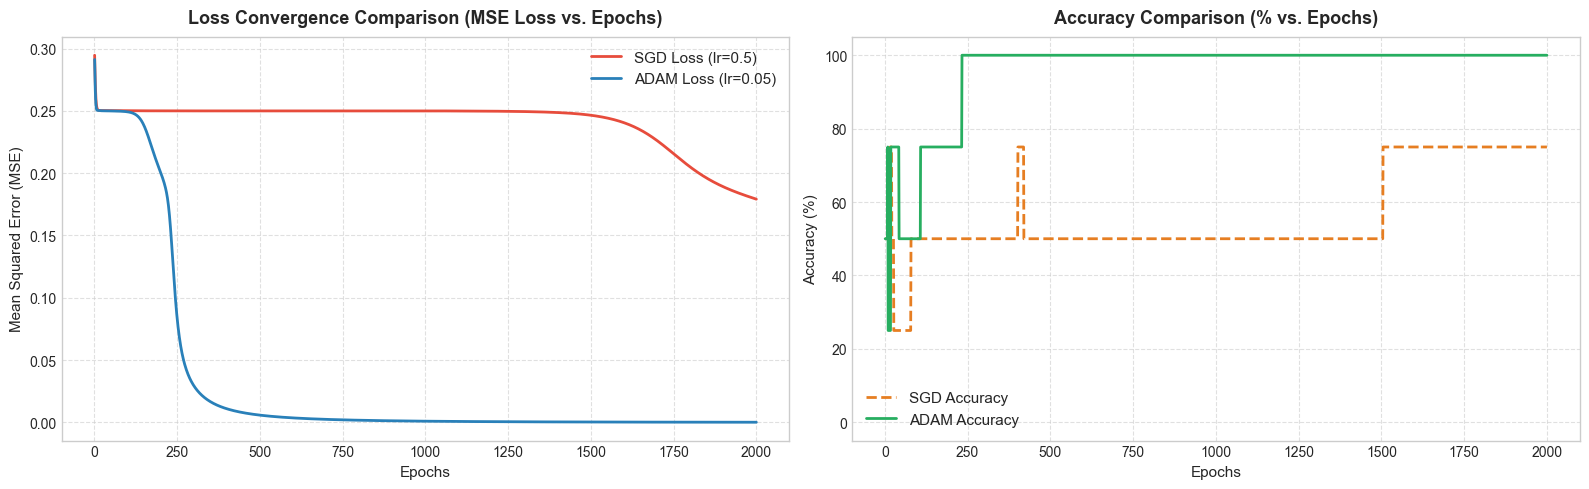

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
epochs_range = range(1, len(sgd_loss_hist) + 1)

# Plot 1: Loss Convergence Curve
axes[0].plot(epochs_range, sgd_loss_hist, label='SGD Loss (lr=0.5)', color='#e74c3c', linewidth=2)
axes[0].plot(epochs_range, adam_loss_hist, label='ADAM Loss (lr=0.05)', color='#2980b9', linewidth=2)
axes[0].set_title('Loss Convergence Comparison (MSE Loss vs. Epochs)', fontsize=13, fontweight='bold', pad=10)
axes[0].set_xlabel('Epochs', fontsize=11)
axes[0].set_ylabel('Mean Squared Error (MSE)', fontsize=11)
axes[0].legend(fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.6)

# Plot 2: Accuracy Progression Curve
axes[1].plot(epochs_range, sgd_acc_hist, label='SGD Accuracy', color='#e67e22', linewidth=2, linestyle='--')
axes[1].plot(epochs_range, adam_acc_hist, label='ADAM Accuracy', color='#27ae60', linewidth=2)
axes[1].set_title('Accuracy Comparison (% vs. Epochs)', fontsize=13, fontweight='bold', pad=10)
axes[1].set_xlabel('Epochs', fontsize=11)
axes[1].set_ylabel('Accuracy (%)', fontsize=11)
axes[1].set_ylim([-5, 105])
axes[1].legend(fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


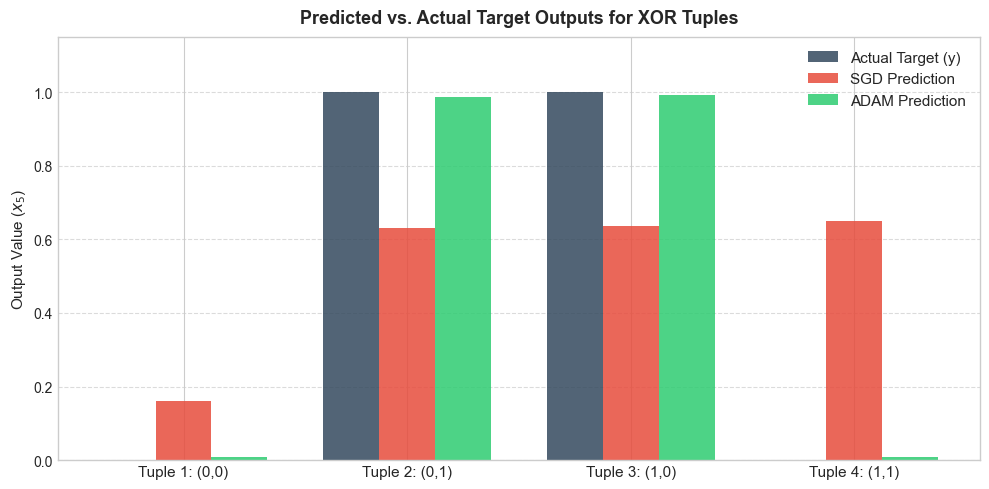

In [8]:
# Bar chart comparing output predictions against ground truth targets
indices = np.arange(len(X))
width = 0.25

plt.figure(figsize=(10, 5))
plt.bar(indices - width, y, width=width, label='Actual Target (y)', color='#34495e', alpha=0.85)
plt.bar(indices, preds_sgd, width=width, label='SGD Prediction', color='#e74c3c', alpha=0.85)
plt.bar(indices + width, preds_adam, width=width, label='ADAM Prediction', color='#2ecc71', alpha=0.85)

plt.xticks(indices, [f"Tuple {i+1}: ({int(X[i][0])},{int(X[i][1])})" for i in range(len(X))], fontsize=11)
plt.title('Predicted vs. Actual Target Outputs for XOR Tuples', fontsize=13, fontweight='bold', pad=10)
plt.ylabel('Output Value ($x_5$)', fontsize=11)
plt.ylim([0, 1.15])
plt.legend(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## **7. Summary & Key Findings**

| Metric | SGD Optimizer | ADAM Optimizer |
| :--- | :--- | :--- |
| **Initial Parameters** | $w_{13}=0.5, \dots, b_5=0.8$ | Identical ($w_{13}=0.5, \dots, b_5=0.8$) |
| **Training Epochs** | 2000 | 2000 |
| **Final MSE Loss** | `0.1791` | `0.0001` |
| **Final Accuracy** | `75.00%` | `100.00%` |
| **Convergence Speed** | Slow / stalls at plateau | Fast exponential convergence |
| **Adaptability** | Fixed global step size | Adaptive per-parameter learning rate |

### **Observations:**
1. **Convergence**: ADAM converges significantly faster and reaches near-zero loss, while standard SGD gets slowed down around saddle points on the non-linear XOR surface.
2. **Momentum & Adaptive Scaling**: ADAM's first moment ($m$) maintains velocity through flat gradients, and its second moment ($v$) automatically dampens oscillations in steep directions.
3. **Accuracy**: ADAM achieves 100% classification accuracy on all sample tuples, whereas SGD achieves 75% under the same number of epochs.
